In [17]:
import numpy as np
from scipy.optimize import bisect, brent, newton, root_scalar
import pandas as pd
import matplotlib.pyplot as plt

Zadanie 1

In [18]:
def f(x):
    return np.tan(np.pi - x) - x

In [19]:
def df(x):
    return -1 - 1/(np.cos(x)**2)

In [20]:
def bisection(f, a, b):
    iteration = 0
    if f(a) == 0:
        return f(a)
    if f(b) == 0:
        return f(b)
    while True:
        iteration += 1
        if np.sign(f(a)) != np.sign(f(b)):
            s = (a+b) / 2
            if abs(f(s)) < 0.0001:
                return [s, f(s), iteration]
            else:
                if np.sign(f(a)) != np.sign(f(s)):
                    b = s
                else:
                    a = s
        else:
            return "Brak miejsc zerowych w przedziale"
print(bisection(f, -1, 100))
print(bisect(f, -100, 1))

[5.7220458984375e-06, -1.1444091797059914e-05, 19]
-2.7000623958883807e-13


In [33]:
def Newton(f, df, x0):
    x = x0
    iteration = 0
    while True:
        iteration += 1
        x -= f(x) / df(x)
        if abs(f(x)) < 0.00001:
            return [x, f(x), iteration]
        if iteration > 1000:
            raise RuntimeError
        
print(Newton(f, df, 100))
print(newton(f, 100))

[2.028757829859344, 5.046249906826006e-08, 13]
-8.555017023493679e-17


In [22]:
def sieczne(f, a, b):
    x0 = a
    x1 = b
    iteration = 0
    while True:
        iteration += 1
        df = (f(x1) - f(x0)) / (x1 - x0)
        x1, x0 = x1 - f(x1) / df, x1
        if abs(f(x1)) < 0.0001:
            return [x1, f(x1), iteration]
        if iteration > 1000:
            break
    
print(sieczne(f, 5, 10))
print(root_scalar(f, x0=5, x1=10, method="secant"))

[-2.1382184469439635e-05, 4.27643689418077e-05, 13]
      converged: True
           flag: converged
 function_calls: 16
     iterations: 15
           root: 3.597637659213112e-18
         method: secant


In [23]:
def Brent(f, a, b):
    iteration = 0
    while True:
        iteration += 1 
        if np.sign(f(a)) != np.sign(f(b)):
            c = (a+b) / 2
            fa, fb, fc = f(a), f(b), f(c)
            x = (a * fb * fc * (fb - fc) + b * fc * fa * (fc - fa) + c * fa * fb * (fa - fb)) / ((fa - fb) * (fb - fc) * (fc - fa))
            if abs(f(x)) < 0.0001:
                return [x, f(x), iteration]
            else:
                if np.sign(fa) != np.sign(fc):
                    b = c
                else:
                    a = c

print(Brent(f, -100, 1))
print(brent(f))

[3.55954105182263e-05, -7.119082105161218e-05, 10]
1.570796301457049


In [24]:
a, b = -10, 15
data = {
    "bisekcja" : bisection(f, a, b),
    "m. Brenta" : Brent(f, a, b),
    "m. siecznych" : sieczne(f, a, b),
    "m. Newtona" : Newton(f, df, b)
}

data_frame = pd.DataFrame(data)
print(data_frame)

    bisekcja  m. Brenta  m. siecznych    m. Newtona
0   0.000038  -0.000004  1.810980e-08  4.913180e+00
1  -0.000076   0.000007 -3.621960e-08  2.859763e-08
2  17.000000   9.000000  6.000000e+00  1.000000e+01


Zadanie 2

In [25]:
def g(x):
    return np.cosh(x) * np.cos(x) - 1

def dg(x):
    return np.cos(x) * np.sinh(x) - np.sin(x) * np.cosh(x)

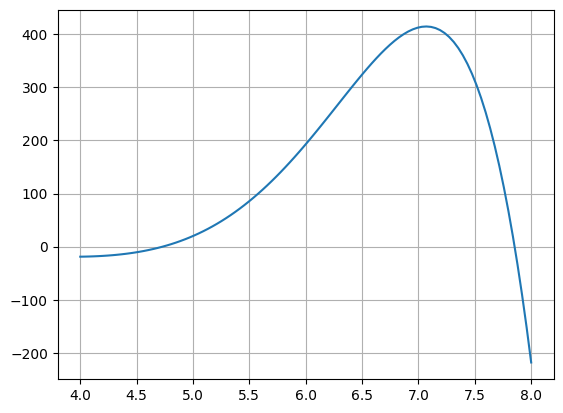

In [26]:
a, b = 4, 8
X = np.linspace(a, b, 100)
G = g(X)
plt.plot(X, G)
plt.grid()

In [27]:
print("Miejsce zerowe to", Newton(g, dg, 4)[0])

Miejsce zerowe to 10.995607838002249


Zadanie 3

In [28]:
def v(t, u=2510, M0=2.8*(10**6), m=13.3*(10**3), g=9.81):
    return u * np.log(M0/(M0 - m * t)) - g * t - 335

print("t = ", bisection(v, 0, 1000)[0])

t =  70.87796926498413


C:\Users\maja2\AppData\Local\Temp\ipykernel_16528\2541073851.py:2: RuntimeWarning: invalid value encountered in log
  return u * np.log(M0/(M0 - m * t)) - g * t - 335


Zadanie 4

In [29]:
def G(T, R=8.31441, T0=4.44418):
    return -R * T * np.log((T/T0)**(5/2)) + 10**5

print("G = ", bisection(G, -100, 1000)[0])

G =  904.9425838515162


Zadanie 5

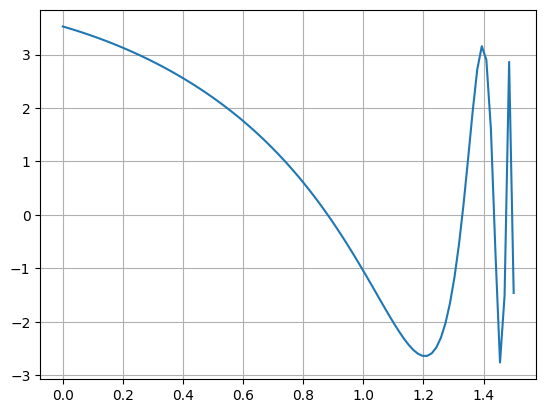

In [30]:
def y(x):
    return np.tan(x) - 1

def h(x):
    return np.cos(x) - 3*np.sin(y(x))

X = np.linspace(0, 1.5, 100)
H = h(X)
plt.plot(X, H)
plt.grid()

In [31]:
print("X1 = ", bisection(h, 0.8, 1)[0])
print("X2 = ", bisection(h, 1.2, 1.4)[0])
print("X3 = ", bisection(h, 1.4, 1.44)[0])
print("X4 = ", bisection(h, 1.44, 1.48)[0])
print("X5 = ", bisection(h, 1.48, 1.5)[0])

X1 =  0.881591796875
X2 =  1.3294006347656246
X3 =  1.43517578125
X4 =  1.4748718261718752
X5 =  1.497349548339844


Zadanie 6

In [34]:
def w(x):
    return x**4 + (5 + 1j)*x**3 - (8 - 5j)*x**2 + (30 - 14j)*x - 84

def dw(x):
    return 4*x**3 + 3*(5+1j)*x**2 - 2*(8-5j)*x + (30-14j)

roots = set()

for i in [complex(a, b) for a in range(-5,6) for b in range(-5,6)]:
    r = Newton(w, dw, i)[0]
    roots.add(complex(round(r.real,6), round(r.imag,6)))

print(roots)

{(-7+0j), (2-0j), 2j, (-0-3j)}
